In [1]:
import os
import shutil
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


In [1]:
home = '/home/slava/Documents/netology_ML/Diplom'
bugs_actual_dir = home + '/bugs_actual'
bugs_expected_dir = home + '/bugs_expected'
val_actual_dir = home + '/val_actual' # это не валидация, а валидные скриншоты, просто скопированные одинаковые скрины
val_expected_dir = home + '/val_expected'

output_dir = home + '/dataset'  # целевая папка для объединённых данных

In [73]:
data = []

# Пары с багами (label=1)
for filename in os.listdir(bugs_actual_dir):
    if filename.endswith('.png'):
        actual_path = bugs_actual_dir + '/' + filename
        expected_path = bugs_expected_dir + '/' + filename
        data.append({
            'actual': str(actual_path),
            'expected': str(expected_path),
            'label': 1
        })

# «Чистые» пары (label=0)
for filename in os.listdir(val_actual_dir):
    if filename.endswith('.png'):
        actual_path = val_actual_dir + '/' + filename
        expected_path = val_expected_dir + '/' + filename
        data.append({
            'actual': str(actual_path),
            'expected': str(expected_path),
            'label': 0
        })

df = pd.DataFrame(data)
df.to_csv('labels.csv', index=False)


                                              actual  \
0  /home/slava/Documents/netology_ML/Diplom/bugs_...   
1  /home/slava/Documents/netology_ML/Diplom/bugs_...   
2  /home/slava/Documents/netology_ML/Diplom/bugs_...   
3  /home/slava/Documents/netology_ML/Diplom/bugs_...   
4  /home/slava/Documents/netology_ML/Diplom/bugs_...   

                                            expected  label  
0  /home/slava/Documents/netology_ML/Diplom/bugs_...      1  
1  /home/slava/Documents/netology_ML/Diplom/bugs_...      1  
2  /home/slava/Documents/netology_ML/Diplom/bugs_...      1  
3  /home/slava/Documents/netology_ML/Diplom/bugs_...      1  
4  /home/slava/Documents/netology_ML/Diplom/bugs_...      1  
Всего пар: 200
С багами: 100
Без багов: 100


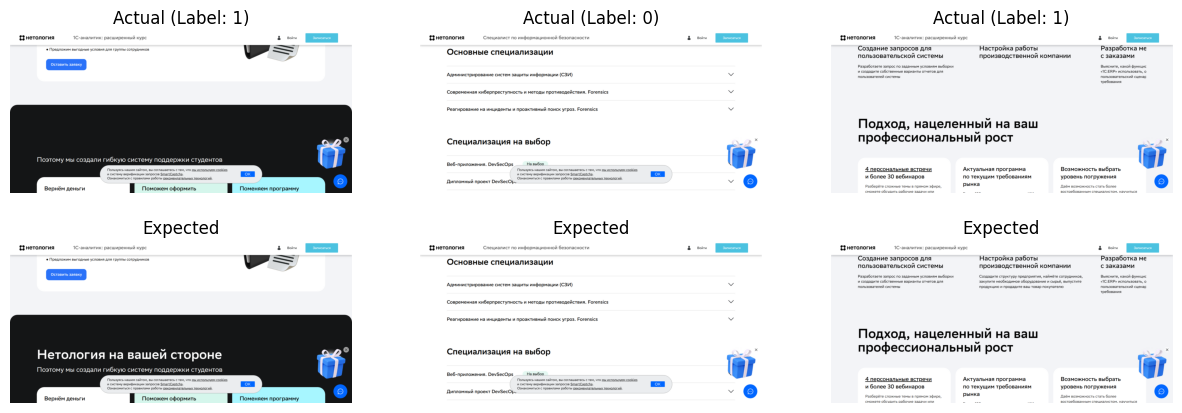

In [75]:
print(df.head())
print(f"Всего пар: {len(df)}")
print(f"С багами: {df['label'].sum()}")
print(f"Без багов: {len(df) - df['label'].sum()}")

def show_samples(df, n=3):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        row = df.sample().iloc[0]
        actual_img = Image.open(row['actual'])
        expected_img = Image.open(row['expected'])
        plt.subplot(2, n, i+1)
        plt.imshow(actual_img)
        plt.title(f'Actual (Label: {row["label"]})')
        plt.axis('off')
        plt.subplot(2, n, n+i+1)
        plt.imshow(expected_img)
        plt.title('Expected')
        plt.axis('off')
    plt.show()

show_samples(df)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   actual    200 non-null    object
 1   expected  200 non-null    object
 2   label     200 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


In [17]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


2026-06-10 22:24:28.290432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [18]:
IMG_SIZE = (256, 512)  # желаемый размер

def process_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация в [0, 1]

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])
    
    # Объединяем в тензор с 2 каналами: [actual, expected]
    combined = np.stack([actual, expected], axis=-1)
    X.append(combined)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 2)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 2)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/home/slava/edu_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-10 22:27:40.641772: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 510, 32)   │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 126, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 499968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    63,996,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,015,265 (244.20 MB)

 Trainable params: 64,015,265 (244.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5562 - loss: 12.3998 - val_accuracy: 0.5250 - val_loss: 3.5131
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5437 - loss: 3.4263 - val_accuracy: 0.4750 - val_loss: 0.8720
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6438 - loss: 0.7202 - val_accuracy: 0.7000 - val_loss: 0.6583
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8313 - loss: 0.5260 - val_accuracy: 0.5250 - val_loss: 0.7747
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8062 - loss: 0.4748 - val_accuracy: 0.7000 - val_loss: 0.6480
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9375 - loss: 0.2706 - val_accuracy: 0.6500 - val_loss: 0.5786
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9312 - loss: 0.1839 - val_accuracy: 0.7000 - val_loss: 0.6465
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9875 - loss: 0.0902 - val_accuracy: 0.7000 - val_loss: 0.7266
Epoch 9/10
5/5

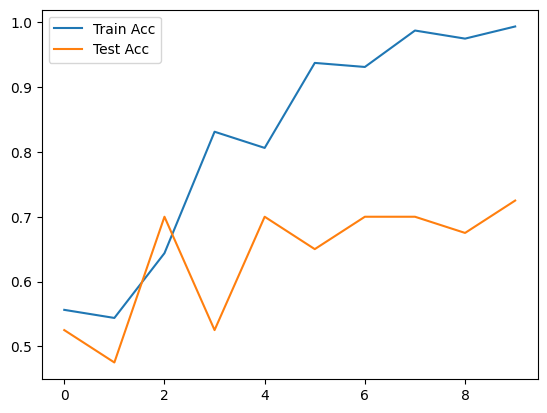

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Test Acc')
plt.legend()
plt.show()


### Предварительные выводы:
Простенькая нейронная сеть не очень хорошо справилась с тривиальной задачей, с которой легко справляется обычная математика. Напомню, что при 100% сравнении, то есть разница лишь в пару пикселей (у нас идет предварительное сжатие), математика из openCV справляется отлично с пропажей элементов.

Так зачем же нам вообще тут нейронка? Мы взяли самый тривиальный случай, чтобы начать с малого. А результат я вижу, когда нейронка сможет на скринщотах с расхождением размеров найти баг в пропадающей кнопке. Вот с этим математика openCV справляется в разы хуже.

Попробуем добавить признаков, и явно укажем разницу в скриншотах, как отдельный признак, чтобы модели было проще.

In [79]:
IMG_SIZE = (256, 512)  # желаемый размер

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])

    # Вычисляем абсолютную разницу (в градациях серого)
    diff = np.abs(actual - expected)  # форма: (h, w)
    
    # Объединяем в тензор с 3 каналами: [actual, expected, diff]
    combined = np.stack([actual, expected, diff], axis=-1)  # (h, w, 3)
    X.append(combined)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 3)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 3)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/home/slava/edu_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 254, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 127, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 125, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 62, 126, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 499968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │    63,996,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,015,553 (244.20 MB)

 Trainable params: 64,015,553 (244.20 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5188 - loss: 13.9497 - val_accuracy: 0.5750 - val_loss: 0.7731
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4375 - loss: 4.5153 - val_accuracy: 0.4750 - val_loss: 0.6812
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6812 - loss: 0.5948 - val_accuracy: 0.5250 - val_loss: 0.7065
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7625 - loss: 0.5049 - val_accuracy: 0.5750 - val_loss: 0.6449
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9125 - loss: 0.3190 - val_accuracy: 0.6000 - val_loss: 0.7418
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9062 - loss: 0.2387 - val_accuracy: 0.6250 - val_loss: 0.8662
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9625 - loss: 0.1288 - val_accuracy: 0.6750 - val_loss: 0.8597
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9438 - loss: 0.1156 - val_accuracy: 0.6750 - val_loss: 0.7960
Epoch 9/10
5/5

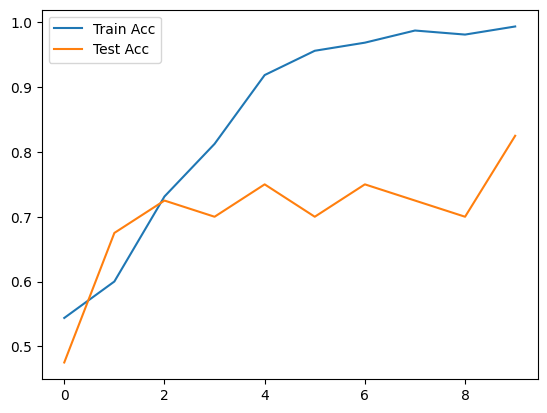

In [26]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Test Acc')
plt.legend()
plt.show()


### Прведварительные выводы:
Не помогло, видимо простая нейронка не справится с этим или у меня где-то ошибка. Проверим...

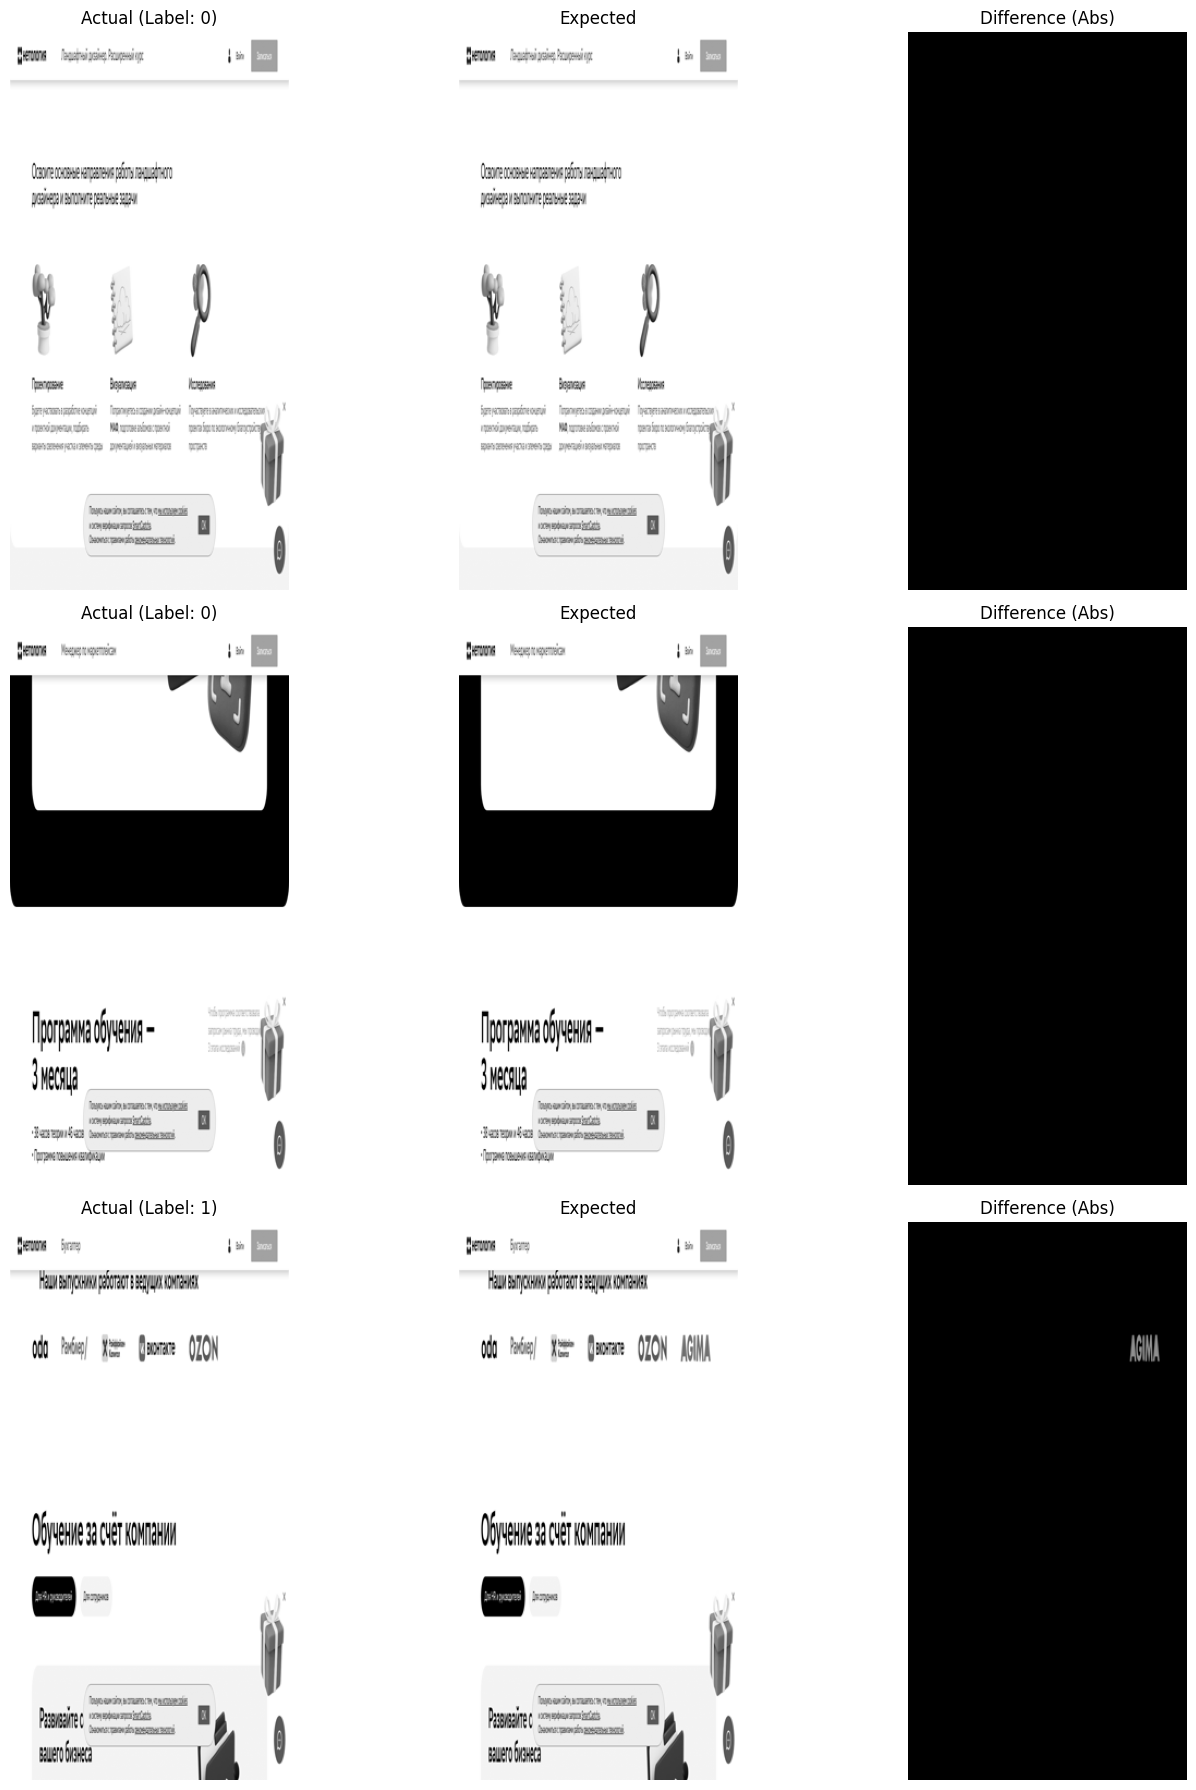

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def show_processed_samples(X, y, num_samples=3):
    plt.figure(figsize=(15, 6 * num_samples))  # размер окна
    
    for i in range(num_samples):
        # Случайный выбор индекса
        idx = np.random.randint(0, len(X))
        sample = X[idx]
        label = y[idx]
        
        # Разделяем каналы
        actual = sample[:, :, 0]  # исходное изображение
        expected = sample[:, :, 1]  # эталон
        diff = sample[:, :, 2]  # разница
        
        # Визуализация
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(actual, cmap='gray')
        plt.title(f'Actual (Label: {label})')
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(expected, cmap='gray')
        plt.title('Expected')
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(diff, cmap='gray', vmin=0, vmax=1)
        plt.title('Difference (Abs)')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Вызов функции
show_processed_samples(X_train, y_train, num_samples=3)


### Предварительные выводы
Ааа ну теперь все становится понятнее:
- я перепутал вертикаль и горизонталь, но это не сильно на результат влияет;
- изображение ещё достаточно четкое и можно ещё больше его сжать, чтобы было меньше параметров;
- в diff очень много мусорных данных нужно удалить нулевые значения.

In [40]:
IMG_SIZE = (64, 32)  # желаемый размер

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])
    
    # Объединяем в тензор с 2 каналами: [actual, expected]
    combined = np.stack([actual, expected], axis=-1)  # (h, w, 3)
    X.append(combined)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 2)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 2)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 30, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 707,489 (2.70 MB)

 Trainable params: 707,489 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5437 - loss: 0.7490 - val_accuracy: 0.5250 - val_loss: 0.6997
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5250 - loss: 0.6927 - val_accuracy: 0.5250 - val_loss: 0.7002
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5562 - loss: 0.6827 - val_accuracy: 0.4250 - val_loss: 0.7106
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6000 - loss: 0.6618 - val_accuracy: 0.4250 - val_loss: 0.7181
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6000 - loss: 0.6356 - val_accuracy: 0.4500 - val_loss: 0.7411
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6687 - loss: 0.6352 - val_accuracy: 0.4500 - val_loss: 0.7526
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6125 - loss: 0.6151 - val_accuracy: 0.4500 - val_loss: 0.7509
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6625 - loss: 0.5899 - val_accuracy: 0.5000 - val_loss: 0.7236


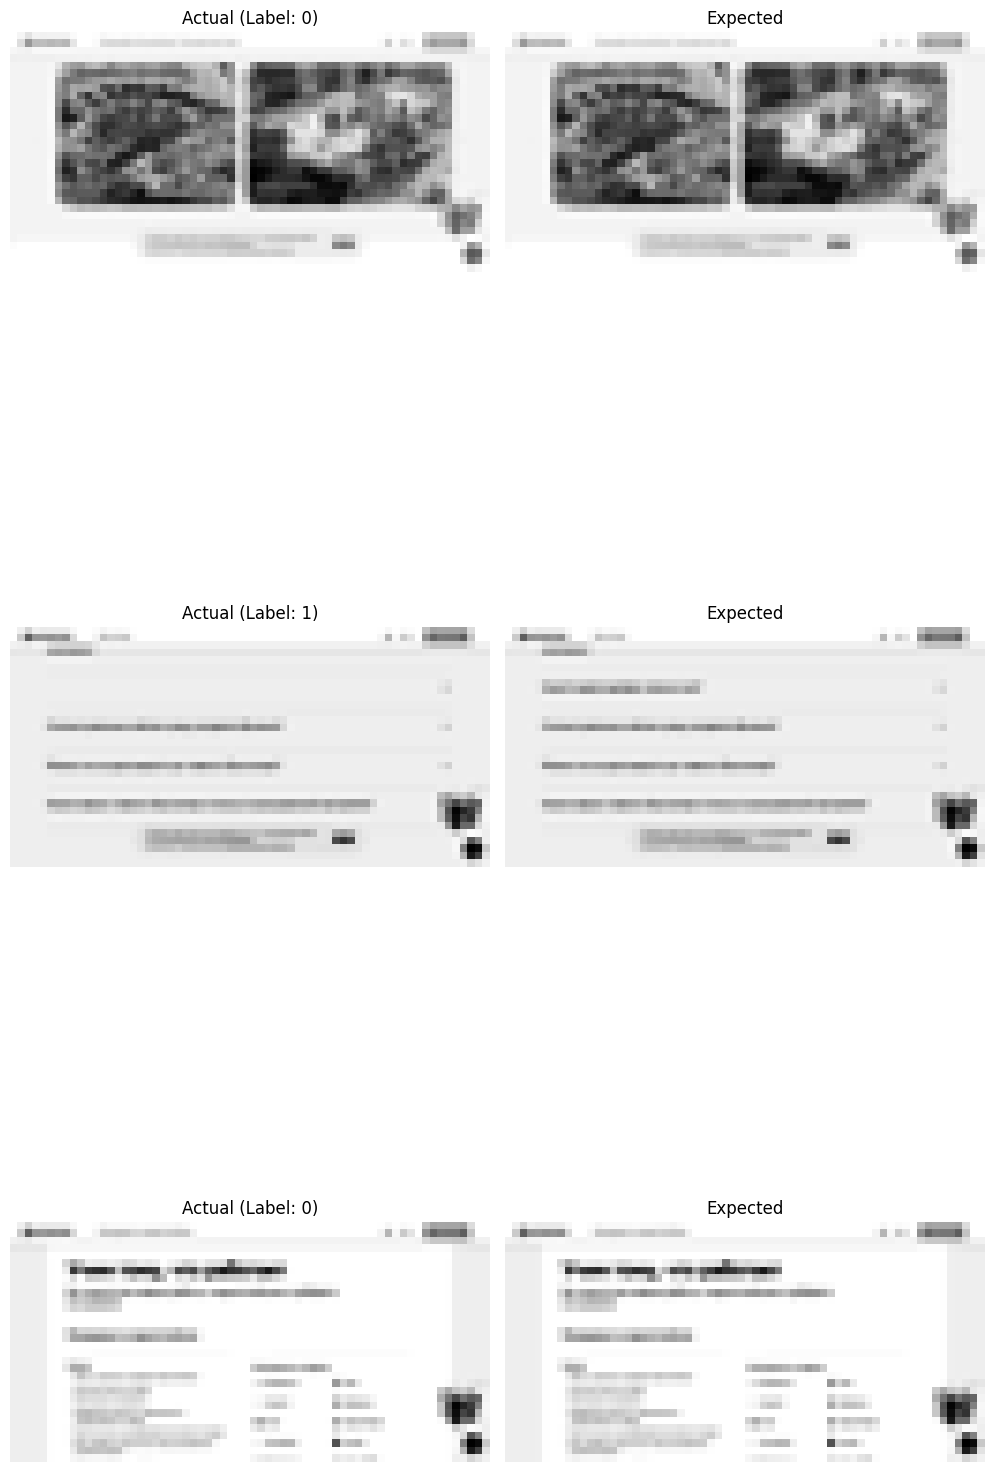

In [43]:
def show_processed_samples(X, y, num_samples=3):
    plt.figure(figsize=(15, 6 * num_samples))  # размер окна
    
    for i in range(num_samples):
        # Случайный выбор индекса
        idx = np.random.randint(0, len(X))
        sample = X[idx]
        label = y[idx]
        
        # Разделяем каналы
        actual = sample[:, :, 0]  # исходное изображение
        expected = sample[:, :, 1]  # эталон
        
        # Визуализация
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(actual, cmap='gray')
        plt.title(f'Actual (Label: {label})')
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(expected, cmap='gray')
        plt.title('Expected')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Вызов функции
show_processed_samples(X_train, y_train, num_samples=3)


### Предварительные выводы:
- Изменение размера очень сильно ускорило обучение. При (256, 128) получилось 65% accuracy, а при (128, 64) было даже лучше 70% accuracy! А при (64, 32) падает до 50%. Получается, что оптимально (128, 64).

In [44]:
IMG_SIZE = (128, 64)  # желаемый размер

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])

    # Вычисляем абсолютную разницу (в градациях серого)
    diff = np.abs(actual - expected)  # форма: (h, w)
    
    # Объединяем в тензор с 3 каналами: [actual, expected, diff]
    combined = np.stack([actual, expected, diff], axis=-1)  # (h, w, 3)
    X.append(combined)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 3)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 3)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 62, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 26880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,440,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,460,289 (13.20 MB)

 Trainable params: 3,460,289 (13.20 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5188 - loss: 0.9164 - val_accuracy: 0.4500 - val_loss: 0.7949
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5750 - loss: 0.6898 - val_accuracy: 0.5250 - val_loss: 0.7013
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6000 - loss: 0.6330 - val_accuracy: 0.5000 - val_loss: 0.7135
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7188 - loss: 0.5652 - val_accuracy: 0.5000 - val_loss: 0.7503
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7375 - loss: 0.4919 - val_accuracy: 0.6250 - val_loss: 0.8026
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7375 - loss: 0.4828 - val_accuracy: 0.5750 - val_loss: 0.7648
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8375 - loss: 0.3776 - val_accuracy: 0.6500 - val_loss: 0.8666
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8313 - loss: 0.3368 - val_accuracy: 0.6500 - val_loss: 1.0317

### Предварительные выводы:
- diff даже мешает, без него получилось 70%. Но если мы преобразуем diff в бинарное значение 1 или 0, то получи 100% сопадение по label, что с одной стороны решит задачу, с другой мы идем к тому, что diff может быть очень большим из-за сдвигов и модель должна уметь с этим работать.
- данная модель не сможет показать большего результата. Можно поэксперементировать с ней, но зачем? Возьмем проверенную сложную модель и предобученную посмотрим как они справятся.

In [76]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam


IMG_SIZE = (128, 64)  # желаемый размер

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])
    
    # Объединяем в тензор с 2 каналами: [actual, expected]
    combined = np.stack([actual, expected], axis=-1)  # (h, w, 3)
    X.append(combined)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 2)
X = np.transpose(X, (0, 2, 1, 3))  # меняем оси 1 (64) и 2 (128)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 2)  # (высота, ширина, 2 канала)


### Создаем базовую модель
# Здесь можно подставить реальную предобученную модель (VGG16, ResNet и др.)
base_input = Input(shape=input_shape, name='base_input')

# Пример базового блока (заменяем на реальную модель при необходимости)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(base_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.4)(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # уменьшить с 1024 до 256
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

base_model = Model(base_input, x, name='base_model')


### Итоговая модель
model = Model(inputs=base_input, outputs=output, name='bug_detector')

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "bug_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ base_input (InputLayer)         │ (None, 128, 64, 2)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 128, 64, 32)    │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 128, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,609 (32.08 MB)

 Trainable params: 8,408,417 (32.08 MB)

 Non-trainable params: 192 (768.00 B)

In [77]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1
)
datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10


/home/slava/edu_env/lib/python3.12/site-packages/keras/src/legacy/preprocessing/image.py:622: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (160, 128, 64, 2) (2 channels).
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.5188 - loss: 8.7829 - val_accuracy: 0.5250 - val_loss: 0.7256
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.4938 - loss: 5.9726 - val_accuracy: 0.5500 - val_loss: 0.9955
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.5250 - loss: 3.7907 - val_accuracy: 0.5250 - val_loss: 0.7059
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.4688 - loss: 2.4163 - val_accuracy: 0.4250 - val_loss: 0.7425
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.5688 - loss: 1.5357 - val_accuracy: 0.6000 - val_loss: 0.7784
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.4938 - loss: 1.1148 - val_accuracy: 0.6000 - val_loss: 1.0229
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.5188 - loss: 0.9736 - val_accuracy: 0.4750 - val_loss: 1.4534
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.6062 - loss: 0.8138 - val_accuracy: 0.4750 - val_loss: 2.7597
Epo

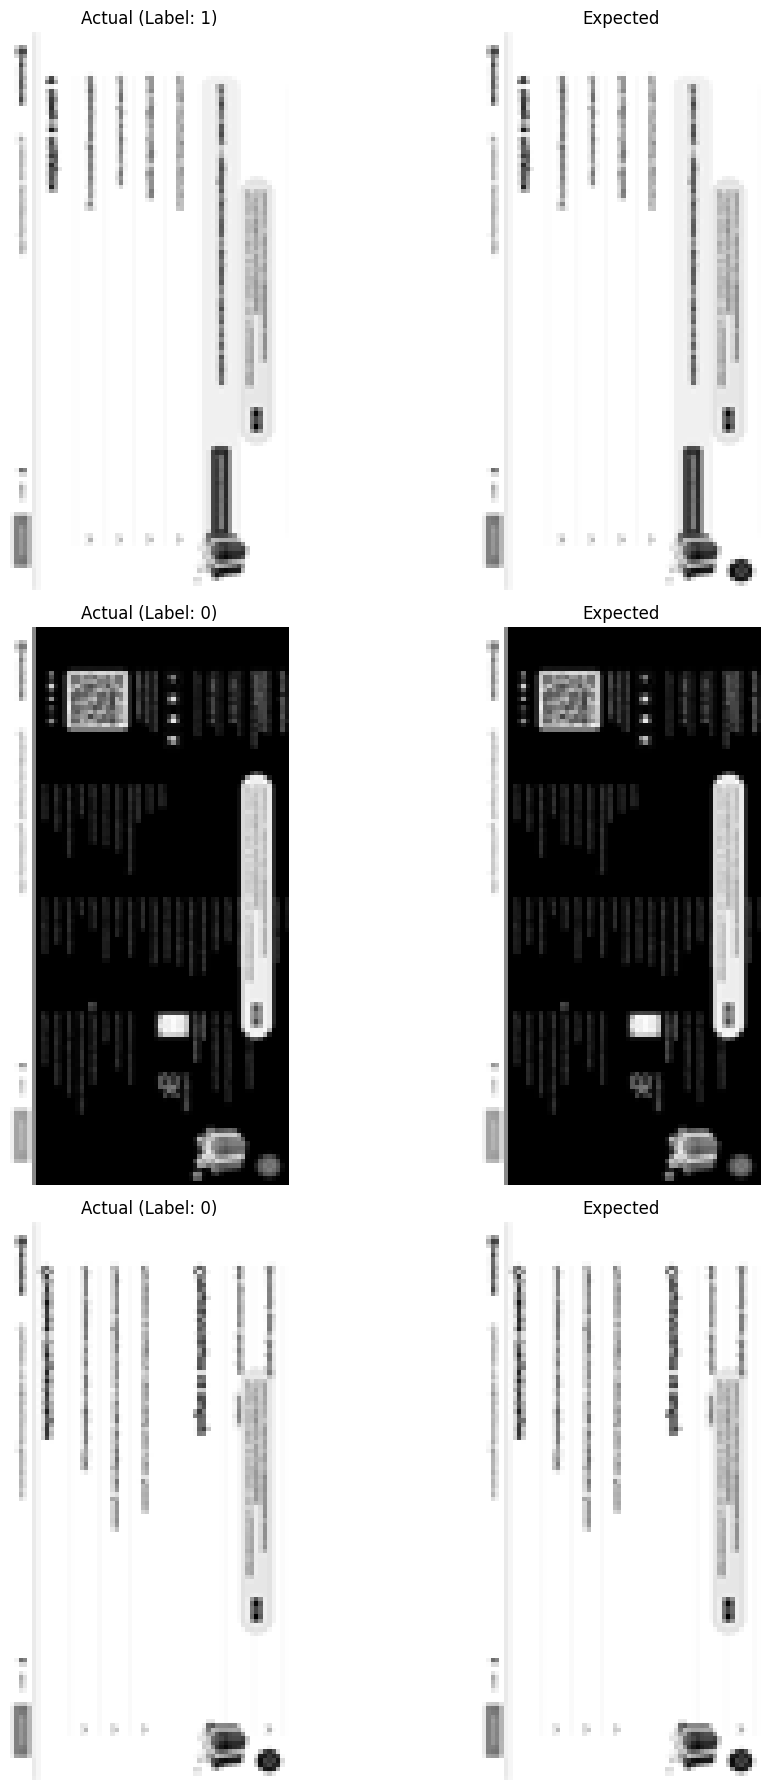

In [78]:
show_processed_samples(X_train, y_train, num_samples=3)

### Предварительные результаты:
Как бы я не пытался обучить с нуля CNN, но она не схватывает условие, если diff = 0, то бага нет. С другой стороны, у меня очень мало данных для обучения этому. Лучший результат пока 0.82. И это когда я передал actual, expected и diff.

Попробуем теперь обучить на карте разницы. diff = (actual - expected)**2

In [85]:
IMG_SIZE = (512, 256)  # желаемый размер

def process_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация в [0, 1]

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])

    diff = (actual - expected)**2
    diff = np.expand_dims(diff, axis=-1)
    X.append(diff)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 2)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 1)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 510, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 255, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 253, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 126, 62, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 499968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │    63,996,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,014,977 (244.20 MB)

 Trainable params: 64,014,977 (244.20 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
print(f"X shape: {X.shape}") 

X shape: (200, 256, 512, 1)


In [87]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5938 - loss: 0.7075 - val_accuracy: 0.2250 - val_loss: 0.6639
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4938 - loss: 0.6582 - val_accuracy: 0.9250 - val_loss: 0.6217
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8062 - loss: 0.5851 - val_accuracy: 0.9750 - val_loss: 0.5387
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9062 - loss: 0.5420 - val_accuracy: 0.9750 - val_loss: 0.4663
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8687 - loss: 0.5099 - val_accuracy: 0.9750 - val_loss: 0.4163
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8562 - loss: 0.4878 - val_accuracy: 0.9750 - val_loss: 0.3866
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8188 - loss: 0.4838 - val_accuracy: 0.9750 - val_loss: 0.3712
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9250 - loss: 0.4493 - val_accuracy: 0.9750 - val_loss: 0.3612
Epoch 9/10
5/5 

In [88]:
IMG_SIZE = (128, 64)  # желаемый размер

def process_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация в [0, 1]

X = []
y = []

for _, row in df.iterrows():
    actual = process_image(row['actual'])
    expected = process_image(row['expected'])

    diff = (actual - expected)**2
    diff = np.expand_dims(diff, axis=-1)
    X.append(diff)
    y.append(row['label'])

X = np.array(X)  # форма: (200, высота, ширина, 2)
y = np.array(y)  # метки: 0 или 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

input_shape = (*IMG_SIZE, 1)  # (высота, ширина, 2 канала)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_58 (Conv2D)              │ (None, 126, 62, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 63, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 61, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 26880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     3,440,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,459,713 (13.20 MB)

 Trainable params: 3,459,713 (13.20 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5750 - loss: 0.6979 - val_accuracy: 0.5250 - val_loss: 0.6724
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4938 - loss: 0.6797 - val_accuracy: 0.5250 - val_loss: 0.6511
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4938 - loss: 0.6567 - val_accuracy: 0.5250 - val_loss: 0.6174
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5375 - loss: 0.6327 - val_accuracy: 0.9500 - val_loss: 0.5754
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7000 - loss: 0.5799 - val_accuracy: 0.9750 - val_loss: 0.5244
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7625 - loss: 0.5641 - val_accuracy: 0.9750 - val_loss: 0.4789
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8813 - loss: 0.5457 - val_accuracy: 0.9750 - val_loss: 0.4455
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8125 - loss: 0.4972 - val_accuracy: 0.9750 - val_loss: 0.4184

## Выводы по оценке качества сверточной нейронной сети по сравнению с чистой математикой CV:
- передача одного лишь diff дал очень хороший результат;
- стабильный результат мы почти сразу получили при сжатии до разрешения (512, 256). Примероно такой же результат, но чуть дольше шла сходимость мы получили у сжатия до разрешения IMG_SIZE = (128, 64). Скорость обучения выросла в 20 раз;
- получили достаточно стабильный результат с ошибкой в 2,5%.

Далее добавим шуму! Ранее мы только уирали элементы, что однозначно баг. А теперь добавим изменения, которые не баги: сдвиги в пару пикселей, динамические элементы, всплывающие окна, то есть то, что чистой математикой CV обойти можно только через костыли: автоматическое закрытие всплывающих окон, игнорирование динамических элементов через закраску, ну вот сдвиги хуже всего, так как даже подгонка через масштабирование или оптимизацию требуют уменьшить порог срабатывания со 100% на пару процентов, а баги как раз могут попасть в это ограничение. Например, перекрашенная кнопка с синего на красный даст разницы менее 1%.
